# Tarea 2: Predicción de redshift fotométrico con métodos de ensamble

## Contexto

El redshift de una galaxia es una cantidad fundamental para estudiar distancias cosmológicas y evolución de galaxias. Idealmente, el redshift se mide mediante espectroscopía, pero obtener espectros para grandes muestras puede ser costoso en tiempo de observación.

Una alternativa ampliamente usada en astronomía es estimar redshifts fotométricos a partir de magnitudes medidas en distintos filtros. En esta actividad trabajaremos con un catálogo de galaxias que contiene fotometría multibanda y redshifts espectroscópicos de referencia. El objetivo será entrenar modelos de machine learning capaces de predecir el redshift usando información fotométrica.

La actividad se plantea como una competencia tipo **Kaggle**: cada grupo entrenará sus modelos con un conjunto de entrenamiento y deberá generar predicciones para un conjunto de test oculto. El ranking final se calculará usando el MSE sobre ese conjunto de test.

A diferencia del notebook que hicimos en clase (donde el dataset ya venía preparado), acá van a recibir el catálogo sin procesar. Van a tener que aplicar tú mismo/a las herramientas de diagnóstico que practicamos  (limpieza de datos, elección de modelo, optimización de hiperparámetros, comparación de criterios de feature importance) sin que nadie te diga de antemano qué decisiones tomar.

---

## Objetivo

Entrenar, comparar y optimizar modelos de regresión basados en árboles y métodos de ensamble para predecir el redshift de galaxias.

El criterio principal de evaluación será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm true},i})^2
$$

El objetivo práctico será obtener el menor MSE posible en el conjunto de test oculto.

---

## Datos

Se entregarán tres archivos:

1. `train_redshift.csv`: contiene las variables fotométricas y el redshift de referencia.
2. `test_redshift.csv`: contiene las mismas variables fotométricas, pero no incluye el redshift.
3. `sample_submission.csv`: muestra el formato esperado para la entrega de predicciones.

El archivo de entrenamiento contiene magnitudes corregidas por apertura en distintos filtros. El redshift de referencia está en la columna: $z_{\rm helio}$

En el archivo de test, esta columna no estará disponible.

---

## Instrucciones generales

Deben desarrollar un notebook reproducible en Python que incluya:

1. Exploración inicial del conjunto de entrenamiento.
2. Preparación de los datos para modelamiento.
3. Construcción o selección de variables predictoras.
4. Separación interna entre entrenamiento y validación, o uso de validación cruzada.
5. Entrenamiento de un modelo baseline con `DecisionTreeRegressor`.
6. Entrenamiento de algún método de ensamble, por ejemplo:

   * `RandomForestRegressor`
   * `ExtraTreesRegressor`
   * `GradientBoostingRegressor`
   * `HistGradientBoostingRegressor`
   * otro método justificado.
7. Optimización de hiperparámetros (puede usar GridSearchCV, RandomizedSearchCV, Optuna, etc)
8. Comparación de modelos usando MSE.
9. Selección del modelo final.
10. Generación de predicciones para `test_redshift.csv`.

El catálogo entregado no está completamente procesado. Parte del trabajo consiste en revisar valores faltantes, valores anómalos y decidir qué variables utilizar o construir.

El conjunto de test no contiene el redshift verdadero. Por lo tanto, no puede ser usado para evaluar ni ajustar modelos. La selección de modelos e hiperparámetros debe realizarse usando únicamente el conjunto de entrenamiento. Pueden crear un conjunto de validación interno (a partir del set de entrenamiento) para la optimización de hiperparámetros, pero el ranking final se calculará de forma ciega, evaluando sus predicciones directamente sobre test_redshift.csv

---

## Entrega de predicciones

Cada grupo debe entregar un archivo llamado:

```text
predicciones.csv
```

con exactamente dos columnas:

| objno_deep2 | z_pred |
| ----------- | ------ |
|             |        |
|             |        |
|             |        |

La columna `objno_deep2` debe coincidir con los identificadores del archivo `test_redshift.csv`.

La columna `z_pred` debe contener el redshift predicho por el modelo final.

El archivo debe tener una predicción para cada objeto del conjunto de test.

El archivo `sample_submission.csv` muestra el formato exacto que debe tener la entrega final. Deben reemplazar los valores de la columna `z_pred` por las predicciones de su modelo, manteniendo los mismos identificadores `objno_deep2`.

---
## Métricas de evaluación

La métrica principal de la competencia será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm spec},i})^2
$$

Además, deberán reportar dos métricas comúnmente usadas en estudios de redshifts fotométricos.

Primero, definimos el residuo normalizado:

$$
\Delta z_i = \frac{z_{{\rm spec},i} - z_{{\rm pred},i}}{1 + z_{{\rm spec},i}}
$$

La dispersión robusta de los residuos se calculará mediante la normalized median absolute deviation:

$$
\sigma_{\rm NMAD} = 1.48 \times {\rm median}\left(
\left| \Delta z_i - {\rm median}(\Delta z) \right|
\right)
$$

También se calculará la fracción de outliers:

$$
\eta = \frac{N_{\rm outliers}}{N}
$$

donde se considera outlier a todo objeto que cumple:

$$
\frac{|z_{\rm spec} - z_{\rm pred}|}{1 + z_{\rm spec}} > 0.15
$$

El ranking de la competencia se calculará usando el MSE sobre el conjunto de test oculto. Sin embargo, en el notebook deben reportar e interpretar las tres métricas: MSE, $\sigma_{\rm NMAD}$ y $\eta$.



## Resultado esperado en el notebook

El notebook debe incluir una tabla resumen similar a la siguiente:

| Modelo        | Features usadas | Hiperparámetros principales | MSE train | MSE validación |
| ------------- | --------------- | --------------------------- | --------- | -------------- |
| Decision Tree |                 |                             |           |                |
| Ensemble      |                 |                             |           |                |

Además, deben incluir:

* un gráfico de $z_{\rm true}$ vs. $z_{\rm pred}$ usando datos de validación
* un análisis de los errores del modelo
* un análisis de las métricas obtenidas
* una discusión sobre las variables más relevantes
* una conclusión justificando el modelo final escogido

---

## Preguntas finales
Respondan brevemente al final del notebook. En todas las preguntas, la respuesta debe apoyarse en gráficos o números específicos de su propio notebook, no en generalidades.

**Sobre la comparación de modelos:**

1. ¿Qué modelo obtuvo el menor MSE en validación?
2. ¿Ese modelo fue elegido como modelo final? Justifiquen.
3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?

**Sobre las variables:**

4. ¿Qué variables parecen ser más importantes para predecir el redshift?
5. Calculen la importancia de variables con al menos dos criterios distintos (por ejemplo, MDI y permutation importance). ¿Coinciden en el ranking? Si no coinciden, ¿a qué atribuyen la diferencia?

**Sobre los errores del modelo:**

6. ¿En qué rangos de redshift falla más el modelo?
7. En el notebook de clase vimos que los métodos basados en árboles tienden a "estrechar" la distribución de predicciones (sobreestiman z bajos, subestiman z altos). ¿Observan este mismo efecto en su propio scatter $z_{\rm true}$
 vs. $z_{\rm pred}$? ¿En qué rango es más pronunciado, y coincide con una menor cantidad de galaxias de entrenamiento en ese rango?
8. Si usaron oob_score en algún modelo, comparen ese valor con el de su validación cruzada. ¿Son consistentes? ¿Qué les dice eso sobre la confiabilidad de OOB para este dataset en particular?

**Sobre el proceso:**

9. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?
10. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?
11. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico? Justifiquen.
---

## Restricciones importantes

No se permite usar información externa al archivo entregado para predecir el redshift del conjunto de test.

No se debe modificar manualmente el archivo de predicciones para objetos individuales.

No se debe usar el conjunto de test para ajustar hiperparámetros ni tomar decisiones de modelamiento. El test oculto se usará solo para la evaluación final.

---

## Entregables

Cada grupo debe entregar:

1. Notebook reproducible en Python.
2. Archivo `predicciones.csv` con las predicciones para el conjunto de test.
3. Breve conclusión final dentro del notebook.

La evaluación considerará tanto el desempeño predictivo como la calidad del procedimiento. El notebook debe ser claro y explicativo del proceso.  El ranking se calculará usando el MSE sobre el conjunto de test oculto, pero la nota no dependerá únicamente del ranking.


#Respuestas

1. El modelo que presentó menor MSE en validación fue el modelo Random forest, ya que alcanzó un MSE de 0.0213.

2. Sí, el modelo fue elegido como la opción final. A pesar de que Random Forest muestra cierta evidencia de sobreajuste (al presentar métricas en entrenamiento muy optimistas, como un $MSE_{\rm train} = 0.0145$), justificamos su elección porque la prioridad analítica es el rendimiento sobre datos no vistos. Random Forest demostró una capacidad de generalización superior, logrando un menor error cuadrático medio ($0.0213$ frente a $0.0228$), una menor dispersión robusta ($\sigma_{\rm NMAD} = 0.0217$ frente a $0.0279$) y una menor tasa de outliers ($4.42\%$ frente a $4.57\%$).

3. La diferencia radicó en la capacidad de controlar la varianza y mejorar la generalización del modelo. Mientras que un árbol de decisión individual mostró un sobreajuste severo pero degradando drásticamente su rendimiento en el conjunto de validación, los métodos de ensamble lograron estabilizar de forma eficaz las predicciones al promediar o corregir múltiples árboles. En este experimento, la estrategia de Bagging implementada por Random Forest demostró ser más efectiva, ofreciendo una mayor robustez y una dispersión de errores más acotada.

4. Las variables fotométricas asociadas a las bandas de onda más largas y los colores derivados de ellas resultaron ser las más determinantes para la predicción. En particular, magnitudes como i_apercor y z_apercor, junto con el color r - i mostraron el mayor capacidad de predicción.

5. Los criterios evaluados no coinciden del todo. Al comparar la importancia por defecto basada en la reducción de impureza (MDI, calculada directamente mediante feature_importances_) con el método de Permutation Importance (evaluado sobre el conjunto de validación), se observan variaciones. Mientras que el método MDI tiende a sobreestimar magnitudes individuales o variables continuas con mucha variabilidad, el criterio de permutación asigna un peso mayor a las bandas infrarrojas (como i_apercor) y a los colores derivados (como r - i).
Esta diferencia se debe al funcionamiento propio de cada método. La importancia por MDI mide cuánto reduce la impureza cada variable dentro del entrenamiento, lo que genera un sesgo inherente hacia características continuas con mucho ruido. Mientras que Permutation Importance mide la pérdida directa de rendimiento del modelo cuando se alteran aleatoriamente los valores de una variable en datos no vistos.

6. El modelo falla más en los extremos del rango. Específicamente, las mayores fallas y la mayor dispersión de residuos se concentran en redshifts altos así como en redshifts muy bajos.

7. Sí, se ve el fenómeno de compresión en la distribución de las predicciones. En la gráfica de dispersión de $z_{\rm true}$ frente a $z_{\rm pred}$, las estimaciones del modelo tienden a aplanarse, sobreestimando sistemáticamente el redshift en la región de $z_{\rm true} < 0.2$ y subestimándolo para valores de $z_{\rm true} > 1.2$.Este efecto es mucho más pronunciado en el extremo de alto redshift ($z > 1.5$). Esto coincide con una marcada escasez de datos en el catálogo de entrenamiento, donde las galaxias con redshifts elevados representan un porcentaje muy bajo del total de la muestra, los árboles de decisión carecen de divisiones suficientes para extender sus hojas a valores extremos, tendiendo a promediar las predicciones hacia la zona densa central de la distribución.

8. Al evaluar el rendimiento del Random Forest mediante la métrica Out-Of-Bag, se obtuvo un $OOB \text{ Score}$ cercano a $0.843$, el cual resulta muy consistente con la precisión observada en el conjunto de validación. Estao nos confirma que la estimación Out-Of-Bag es muy confiable para este conjunto de datos.

9. Existe un sesgo de selección en la muestra de entrenamiento, ya que los datos con redshift espectroscópico tienden a estar sobrerrepresentados por galaxias más brillantes y de menor distancia, lo que dificulta una buena generalización hacia objetos más débiles y también la presencia de observaciones con fotometría ruidosa o con valores faltantes introduce incertidumbre en las estimaciones.

10. La decisión de mayor impacto fue feature engineering, específicamente la creación e inclusión de los colores fotométricos. Los árboles de decisión se benefician mucho de estas variables, ya que los colores miden de forma directa la pendiente del espectro electromagnético de la galaxia y la posición del salto, lo que resulta ser un indicador físico mucho más robusto para determinar el redshift que las magnitudes brutas por separado.

11. No necesariamente, depende principalmente del objetivo y del problema científico. Habrá casos en los que querremos entrenar un modelo a modo de comparación con métodos habituales (como en este caso), y MSE puede resultar una buena métrica, pero también toma relevancia la fracción de outliers principalmente pues te da información sobre donde falla el modelo y qué datos faltan para que mejore. En otras situaciones se requerirá un cierto grado de pureza en un problema de clasificación, lo que sugiere abordarlo desde cierto punto de vista donde un MSE entre las features no siempre resulta óptimo. Toma relevancia el conocer la situación física a modelar, pues define cómo se abordará el problema y las expectativas que tenemos sobre este.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.dpi = 120
plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)

In [ ]:
#Exploración inicial de los datos de entrenamiento
train = pd.read_csv("train_redshift.csv")
train.describe()

,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
count,1.905700e+04,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000
mean,1.250061e+07,214.775328,52.802919,3.102902,23.072000,22.072399,21.474566,21.037788,-22.943618,20.808852,22.200714,-1.924227,-47.986567,0.714946
std,9.721234e+05,0.601017,0.415641,1.313585,21.588971,20.738837,20.670669,20.667991,59.776041,20.659574,76.125181,14.914514,49.629275,0.417994
min,1.100167e+07,213.473160,51.929113,-2.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-0.078525
25%,1.200843e+07,214.310464,52.476931,2.000000,23.671897,23.237811,22.598163,22.014806,-99.000000,21.711408,0.000000,0.000000,-99.000000,0.396693
50%,1.300380e+07,214.782577,52.810978,4.000000,24.323693,23.911843,23.415690,22.912288,21.885385,22.634205,0.000000,0.000000,0.000000,0.688533
75%,1.304796e+07,215.223139,53.111788,4.000000,25.003003,24.439543,23.896741,23.498121,23.242554,23.295065,0.000000,1.000000,0.000000,0.979685
max,1.410175e+07,216.098062,53.694992,4.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,253.000000,1.000000,1.000000,4.500611


Número de datos faltantes para cada columna (99 o -99):
u_apercor      835
g_apercor      724
r_apercor      721
i_apercor      725
i2_apercor    7349
z_apercor      726
dtype: int64


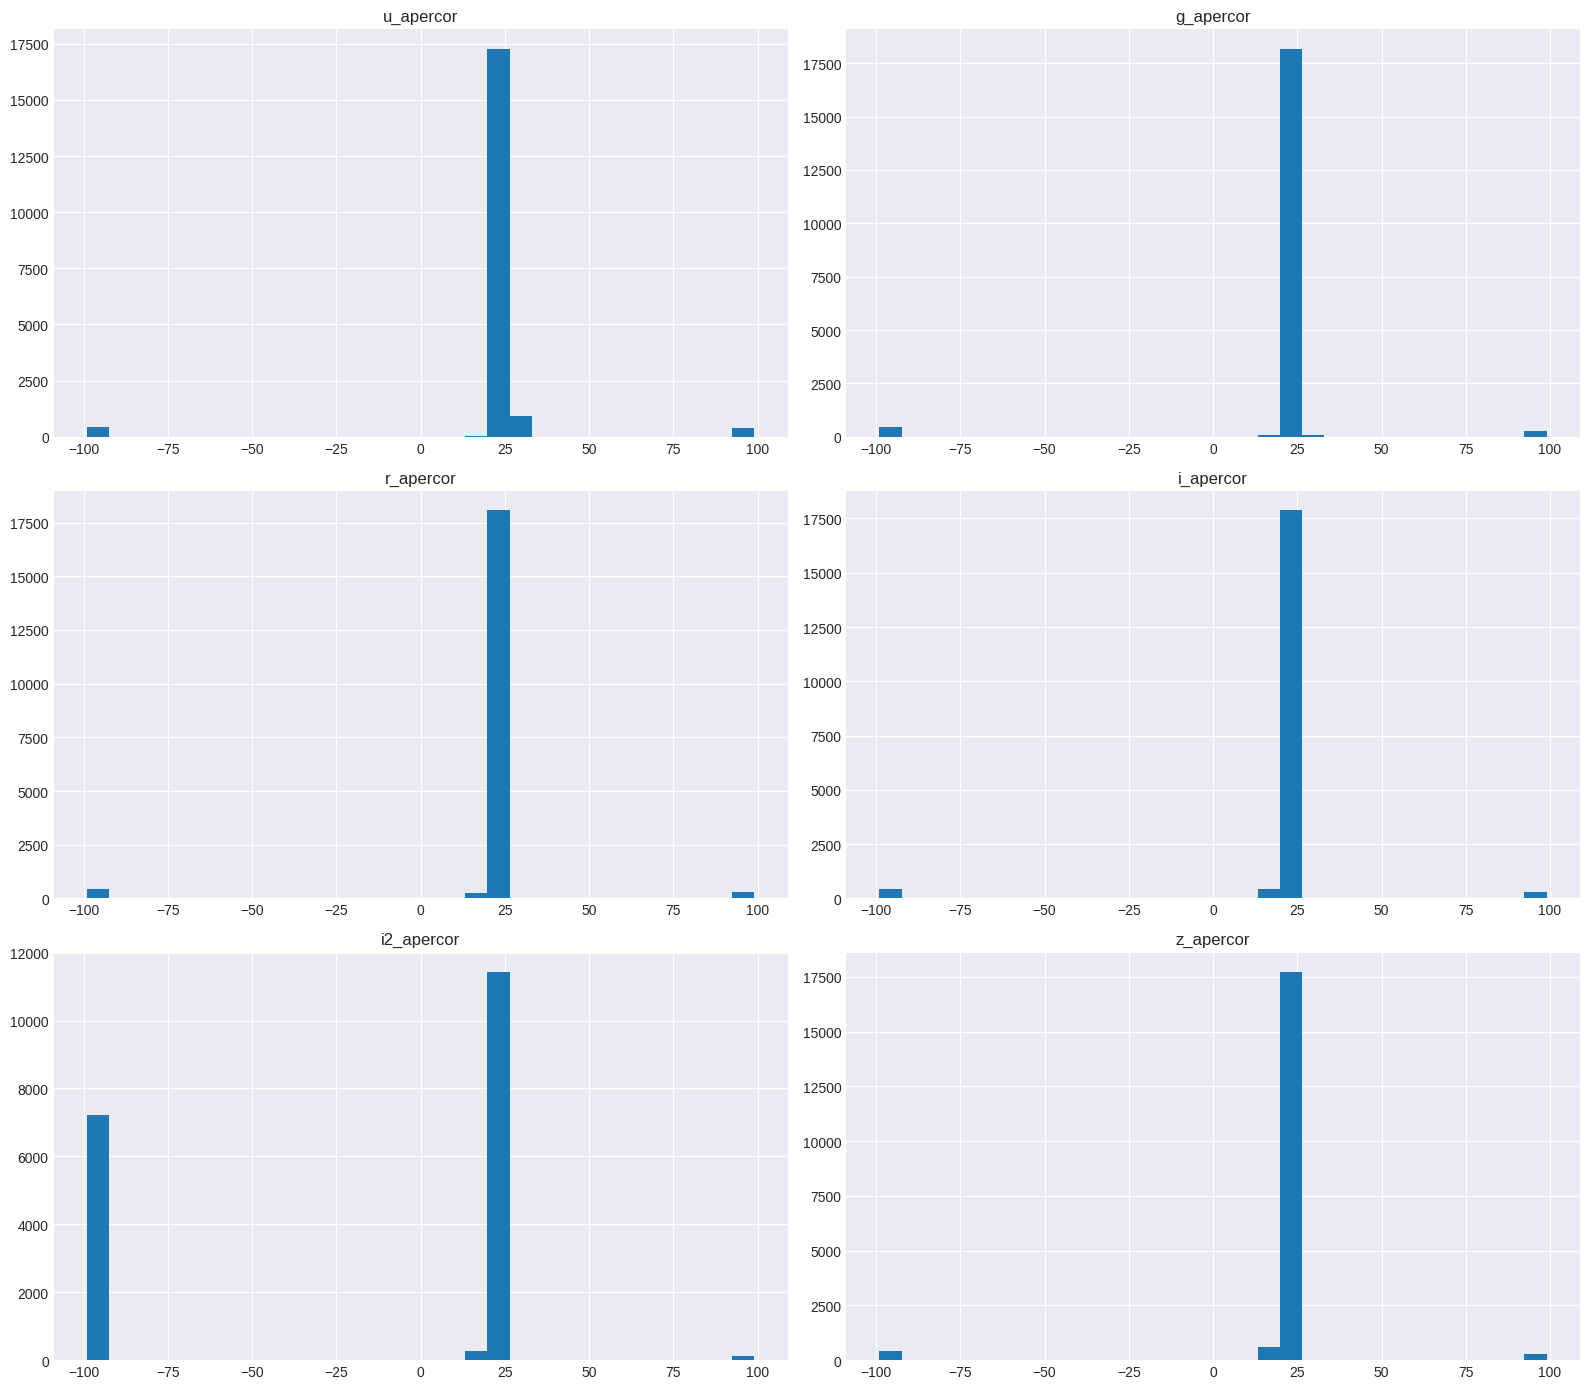

In [ ]:
#Valores anómalos en el dataset de entrenamiento
metadata = ["objno_deep2", "ra_deep2", "dec_deep2"]
bands = ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor']
flags = ["flag_cfhtls", "cfhtls_source", "subaru_source"]
redshift = ["zquality", "zhelio"]

#Número de datos faltantes para cada columna, 99 o -99 para las bandas MAG_APERCOR
missing_values = train[bands].isin([99, -99]).sum()
print("Número de datos faltantes para cada columna (99 o -99):")
print(missing_values)

train.hist(column=bands, bins=30, figsize=(16, 14))
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'zquality'}>,
        <Axes: title={'center': 'zhelio'}>]], dtype=object)

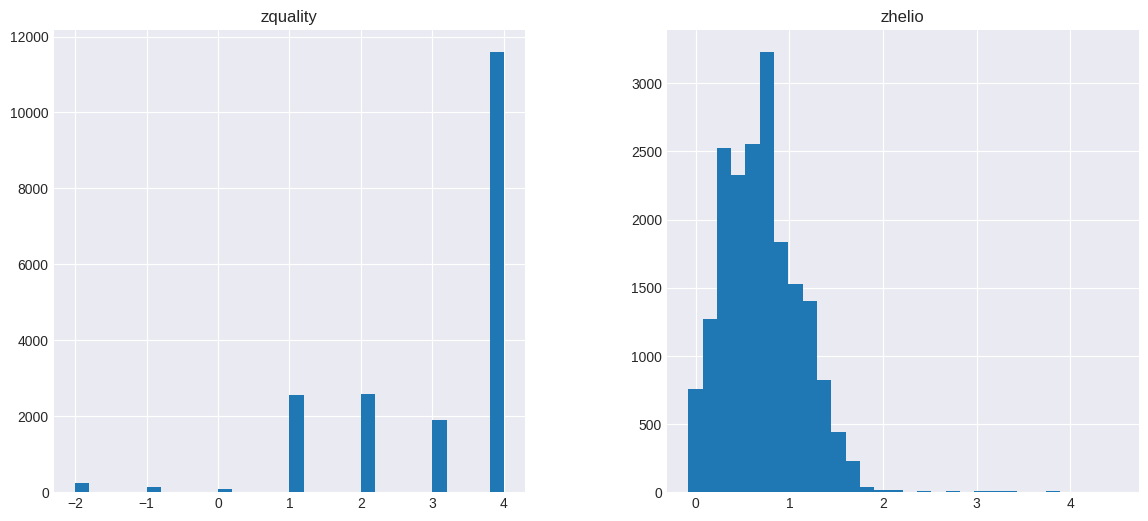

In [ ]:
train.hist(column=redshift, bins=30,figsize=(14, 6))

In [ ]:
for column in flags:
    print(f"\nConteo de valores para la columna {column}:")
    print(train[column].value_counts())


Conteo de valores para la columna flag_cfhtls:
flag_cfhtls
 0      16653
 244     1035
 252      835
-99       439
 1         81
 253        8
 246        3
 245        2
 247        1
Name: count, dtype: int64

Conteo de valores para la columna cfhtls_source:
cfhtls_source
 0     11827
 1      6791
-99      439
Name: count, dtype: int64

Conteo de valores para la columna subaru_source:
subaru_source
-99    9266
 0     6937
 1     2854
Name: count, dtype: int64


Variables categóricas todas.

In [ ]:
mask = train["flag_cfhtls"] == -99

print("Distribución de cfhtls_source cuando flag_cfhtls = -99:")
print(train.loc[mask, "cfhtls_source"].value_counts(dropna=False))

same_value = (train.loc[mask, "cfhtls_source"] == -99).all()
print(f"\n¿Siempre cfhtls_source = -99 cuando flag_cfhtls = -99? {same_value}")

same_value_bands = (train.loc[mask, bands] == -99).all(axis=1)
print(f"\n¿Siempre las bandas MAG_APERCOR = -99 cuando flag_cfhtls = -99? {same_value_bands.all()}")

maskMissingPhotometry = ((train[bands] == -99)).all(axis=1)
print(f"\nNúmero de filas con todas las bandas MAG_APERCOR = -99: {maskMissingPhotometry.sum()}")


Distribución de cfhtls_source cuando flag_cfhtls = -99:
cfhtls_source
-99    439
Name: count, dtype: int64

¿Siempre cfhtls_source = -99 cuando flag_cfhtls = -99? True

¿Siempre las bandas MAG_APERCOR = -99 cuando flag_cfhtls = -99? True

Número de filas con todas las bandas MAG_APERCOR = -99: 439


Cuando `cfhtls_source == -99`, no hay información de ninguna feature. Botaremos estos datos pues no entregan nada. Por otro lado, intuimos que `zquality` es un indicador de la calidad del ajuste de redshift. Tomaremos como primera aproximación valores mayores o iguales a 3.

<Axes: xlabel='zhelio', ylabel='zquality'>

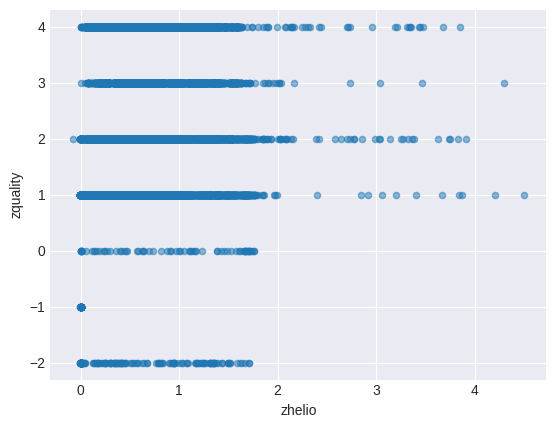

In [ ]:
train.plot.scatter(x="zhelio", y="zquality", alpha=0.5)


In [ ]:
maskZQuality = (train["zquality"] >=3)
cleanedTrain = train[maskZQuality & ~maskMissingPhotometry]
cleanedTrain.describe()


,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
count,1.326500e+04,13265.000000,13265.000000,13265.000000,13265.000000,13265.000000,13265.000000,13265.000000,13265.000000,13265.000000,13265.000000,13265.000000,13265.000000,13265.000000
mean,1.251816e+07,214.788031,52.811657,3.860460,25.180278,24.503062,23.859388,23.375916,-20.365044,23.119623,24.485413,0.357030,-47.193140,0.729862
std,9.659192e+05,0.595605,0.412502,0.346522,8.894687,8.300966,8.326793,8.461832,58.933065,8.467069,73.914439,0.479142,49.595754,0.356933
min,1.100170e+07,213.477225,51.930718,3.000000,17.226409,16.888645,16.678609,16.387059,-99.000000,16.128561,0.000000,0.000000,-99.000000,-0.000516
25%,1.200880e+07,214.330400,52.487855,4.000000,23.556160,23.094887,22.418549,21.845395,-99.000000,21.546442,0.000000,0.000000,-99.000000,0.455568
50%,1.300426e+07,214.787863,52.816577,4.000000,24.174891,23.793346,23.237486,22.701460,21.768222,22.431487,0.000000,0.000000,0.000000,0.716907
75%,1.304795e+07,215.232972,53.115191,4.000000,24.766255,24.310382,23.766384,23.297230,23.036178,23.057950,0.000000,1.000000,0.000000,0.968598
max,1.410175e+07,216.098062,53.689547,4.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,253.000000,1.000000,1.000000,4.298351


Estudiaremos los casos donde hay alguna banda con valor 99

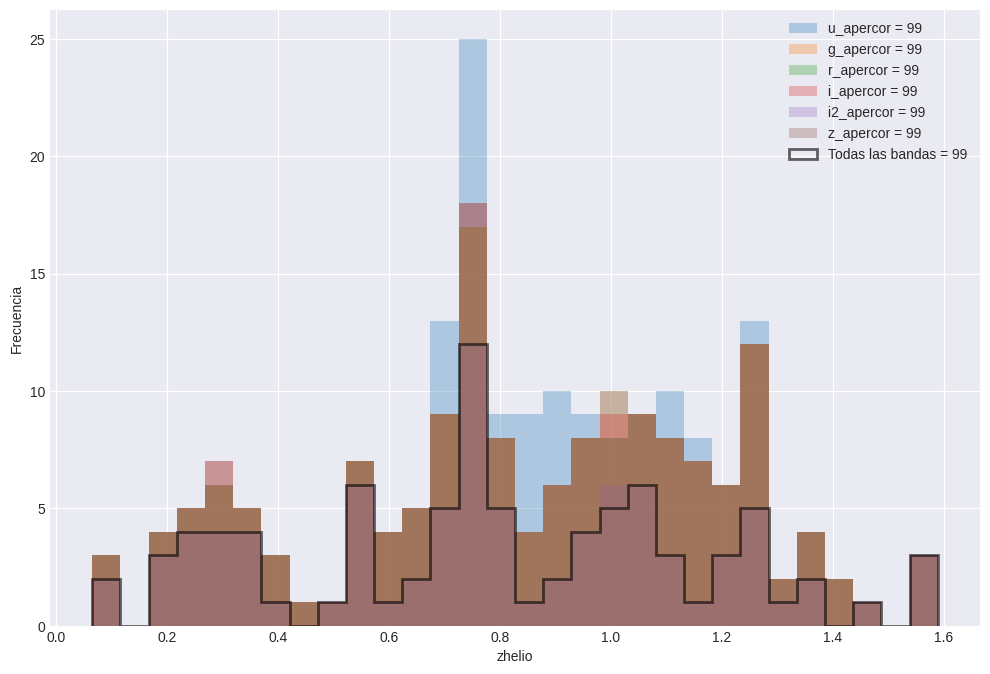

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
maskFull99 = cleanedTrain[bands].isin([99]).all(axis=1)
for band in bands:
    mask = cleanedTrain[band] == 99
    ax.hist(cleanedTrain.loc[mask, "zhelio"], bins=30, alpha=0.3, label=f"{band} = 99",
            histtype='bar')
ax.hist(cleanedTrain.loc[maskFull99, "zhelio"], bins=30, alpha=0.6, label=f"Todas las bandas = 99",
        histtype='step', color="k", linewidth=2)
ax.set_xlabel("zhelio")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.show()

Tal parece ser que no podemos decir nada respecto a la situación donde una banda está en 99, incluso cuando todas están en 99. No dropearemos esos valores, pero añadiremos un flag cuando la banda sea 99

In [ ]:
from sklearn.model_selection import train_test_split

#Filtrando para valores de zhelio > 0
cleanedTrain = cleanedTrain[cleanedTrain['zhelio'] >= 0].copy()
z_bins = pd.cut(cleanedTrain['zhelio'], bins=[0, 0.3, 0.6, 1.0, 1.5, 2.0, cleanedTrain['zhelio'].max()],
                include_lowest=True)

#Se hará un split de la data para tener una evaluación real del modelo
X_pre_split = cleanedTrain.copy().drop(columns=redshift)
X_pre_split.drop(columns=metadata, inplace=True)
Y_pre_split = cleanedTrain["zhelio"].copy()

# Split estratificado según los bins dados en z, pues hacia redshift alto habrá menos datos y buscamos mantener esa distribución
X_train, X_holdout, Y_train, Y_holdout = train_test_split(
    X_pre_split, Y_pre_split, test_size=0.15, random_state=42, stratify=z_bins)

#Esto para no tener que cambiar los nombres de las variables hacia abajo
X = X_train.copy()
Y = Y_train.copy()

#Construcción de colores
X["u-g"] = X["u_apercor"] - X["g_apercor"]
X["g-r"] = X["g_apercor"] - X["r_apercor"]
X["r-i"] = X["r_apercor"] - X["i_apercor"]
X["i-z"] = X["i_apercor"] - X["z_apercor"]
X["r-i2"] = X["r_apercor"] - X["i2_apercor"]
X["u-r"] = X["u_apercor"] - X["r_apercor"]

# HGB maneja nativamente NaNs. Reemplazamos los 99 por NaN
X_HGB = X.copy()
X_HGB[bands] = X_HGB[bands].replace(99, np.nan)

# Creación de flags indicadores de valores faltantes (99 o -99) para cada banda MAG_APERCOR
for band in bands:
    band_name = band.split('_')[0]
    maskneg99 = (X[band] == -99)
    if band == "i2_apercor":
      X[f"{band_name}_isneg99"] = maskneg99.astype(int)
    mask99 = (X[band] == 99)
    X[f"{band_name}_is99"] = mask99.astype(int)
    print(f"Número de valores faltantes para {band} (99 o -99): {mask99.sum() + maskneg99.sum()}")

def MSE(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)
def sigma_nmad(y_true, y_pred):
    residuals = (y_true - y_pred) / (1 + y_true)
    return 1.48 * np.median(np.abs(residuals - np.median(residuals)))
def outlier_fraction(y_true, y_pred, threshold=0.15):
    residuals = (y_true - y_pred) / (1 + y_true)
    outliers = np.abs(residuals) > threshold
    return np.mean(outliers)

def metrics(y_true, y_pred):
    mse = MSE(y_true, y_pred)
    sigma = sigma_nmad(y_true, y_pred)
    outlier_frac = outlier_fraction(y_true, y_pred)
    print(f"MSE: {mse:.4f}")
    print(f"Sigma NMAD: {sigma:.4f}")
    print(f"Fracción de outliers: {outlier_frac:.4f}")
    return mse, sigma, outlier_frac

Número de valores faltantes para u_apercor (99 o -99): 162
Número de valores faltantes para g_apercor (99 o -99): 138
Número de valores faltantes para r_apercor (99 o -99): 136
Número de valores faltantes para i_apercor (99 o -99): 138
Número de valores faltantes para i2_apercor (99 o -99): 4089
Número de valores faltantes para z_apercor (99 o -99): 137


In [ ]:
X.describe()

,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,u-g,...,i-z,r-i2,u-r,u_is99,g_is99,r_is99,i_is99,i2_isneg99,i2_is99,z_is99
count,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000,...,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000,11271.000000
mean,25.196879,24.515337,23.872866,23.386812,-20.217604,23.130945,24.049862,0.355958,-47.055896,0.681543,...,0.255867,44.090470,1.324013,0.014373,0.012244,0.012066,0.012244,0.355958,0.006832,0.012155
std,8.978928,8.361638,8.379060,8.497444,58.916088,8.498251,73.323535,0.478824,49.590460,3.534300,...,0.720403,58.960466,3.645388,0.119029,0.109977,0.109187,0.109977,0.478824,0.082375,0.109583
min,17.226409,16.888645,16.821719,16.471368,-99.000000,16.197118,0.000000,0.000000,-99.000000,-69.051726,...,-7.987273,-74.344499,-0.310032,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.554439,23.090264,22.420736,21.850375,-99.000000,21.554063,0.000000,0.000000,-99.000000,0.190435,...,0.127679,0.340677,0.566703,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,24.174887,23.795014,23.239693,22.701658,21.785237,22.436869,0.000000,0.000000,0.000000,0.388073,...,0.224262,0.660195,1.014040,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,24.760110,24.310173,23.769396,23.303524,23.042461,23.059738,0.000000,1.000000,0.000000,0.714642,...,0.360984,121.551911,1.438174,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,253.000000,1.000000,1.000000,75.388758,...,73.281811,198.000000,76.583187,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Benchmarking de modelos

In [ ]:
from sklearn.model_selection import  cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, GradientBoostingRegressor

cv = KFold(n_splits=20, shuffle=True, random_state=42)

scoresSimpleTree = cross_val_score(DecisionTreeRegressor(random_state=42),
                                   X, Y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-2, verbose=1)

scoresHGB = cross_val_score(HistGradientBoostingRegressor(random_state=42, categorical_features=flags,
                                                          max_iter=200),
                            X_HGB, Y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-2, verbose=1)

scoresRF = cross_val_score(RandomForestRegressor(random_state=42, n_estimators=200),
                           X, Y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-2, verbose=1)

scoresGB = cross_val_score(GradientBoostingRegressor(random_state=42, n_estimators=200),
                           X, Y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-2, verbose=1)

mseSimpleTree = -scoresSimpleTree
mseHGB = -scoresHGB
mseRF = -scoresRF
mseGB = -scoresGB


In [ ]:
# Lo puse para evitar correr celdas, luego quitar
from sklearn.model_selection import  cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, GradientBoostingRegressor

In [ ]:


print(f"MSE del árbol de decisión simple: {mseSimpleTree.mean():.4f}, desviación estándar: {mseSimpleTree.std():.4f}")
print(f"MSE del HistGradientBoostingRegressor: {mseHGB.mean():.4f}, desviación estándar: {mseHGB.std():.4f}")
print(f"MSE del RandomForestRegressor: {mseRF.mean():.4f}, desviación estándar: {mseRF.std():.4f}")
print(f"MSE del GradientBoostingRegressor: {mseGB.mean():.4f}, desviación estándar: {mseGB.std():.4f}")

plt.figure(figsize=(14, 8))
plt.boxplot([mseSimpleTree, mseHGB, mseRF, mseGB], tick_labels=["Árbol de decisión simple",
                                                                "HistGradientBoostingRegressor",
                                                                "RandomForestRegressor",
                                                                "GradientBoostingRegressor"])
plt.ylabel("MSE")
plt.title("Comparación de MSE entre modelos")
plt.show()
plt.tight_layout()

NameError: name 'mseSimpleTree' is not defined

In [ ]:
# Optimización de hiperparámetros para HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)


param_grid = {"learning_rate" : [0.01, 0.05, 0.1, 0.2],
              "max_leaf_nodes" : [15, 31, 63, 127],
              "max_depth" : [None, 3, 5, 7, 10],
              "min_samples_leaf": np.random.randint(10, 100, size=5).tolist()}
HGB_model = HistGradientBoostingRegressor(random_state=42, categorical_features=flags, max_iter=200)

HGB_tuning = RandomizedSearchCV(HGB_model, param_grid, n_iter=75,
                                cv=kf, scoring="neg_mean_squared_error", random_state=42, n_jobs=-1,
                                return_train_score=True)

HGB_tuning.fit(X_HGB, Y)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=HistGradientBoostingRegressor(categorical_features=['flag_cfhtls',
                                                                                 'cfhtls_source',
                                                                                 'subaru_source'],
                                                           max_iter=200,
                                                           random_state=42),
                   n_iter=75, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [None, 3, 5, 7, 10],
                                        'max_leaf_nodes': [15, 31, 63, 127],
                                        'min_samples_leaf': [33, 12, 31, 62,
                                                             11]},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error')

In [ ]:
print("Mejores hiperparámetros encontrados:")
print(HGB_tuning.best_params_)
print("Métricas en validación")
metrics(Y, HGB_tuning.predict(X_HGB))

Mejores hiperparámetros encontrados:
{'min_samples_leaf': 11, 'max_leaf_nodes': 63, 'max_depth': None, 'learning_rate': 0.05}
Mejor MSE encontrado: 0.0275


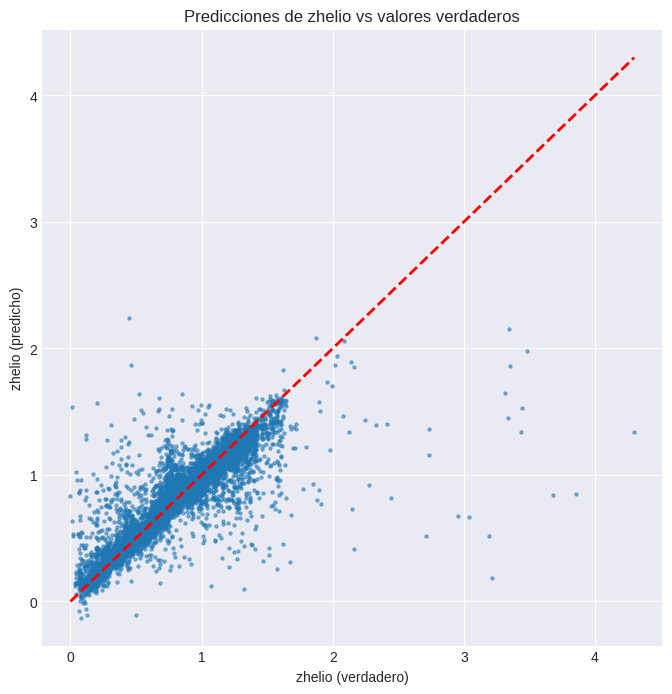

In [ ]:
from sklearn.model_selection import cross_val_predict
bestModel = HGB_tuning.best_estimator_
z_predict = cross_val_predict(bestModel, X_HGB, Y, cv=kf)

plt.figure(figsize=(8, 8))
plt.scatter(Y, z_predict, alpha=0.5, s=5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
plt.xlabel("zhelio (verdadero)")
plt.ylabel("zhelio (predicho)")
plt.title("Predicciones de zhelio vs valores verdaderos")
plt.show()

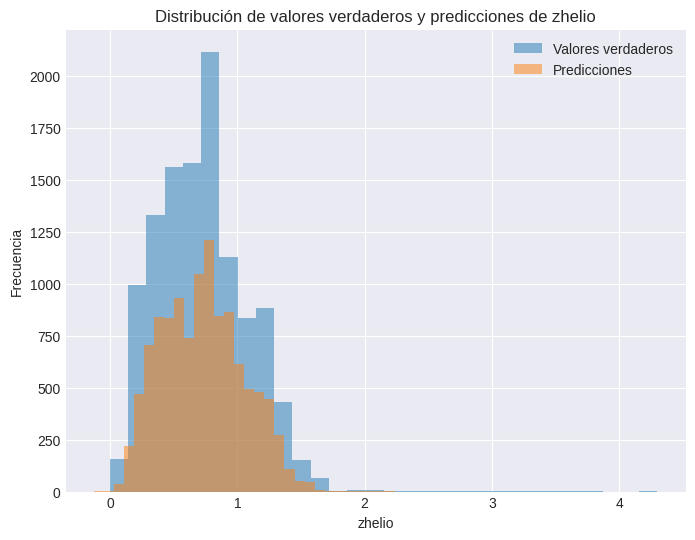

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(Y, bins=30, alpha=0.5, label="Valores verdaderos")
plt.hist(z_predict, bins=30, alpha=0.5, label="Predicciones")
plt.xlabel("zhelio")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de valores verdaderos y predicciones de zhelio")
plt.show()

Importancia de las características según la importancia de permutación:
r-i              0.678327
u-g              0.413094
u-r              0.360807
g-r              0.319648
i-z              0.299379
r-i2             0.031326
u_apercor        0.018384
r_apercor        0.010402
z_apercor        0.009052
flag_cfhtls      0.006766
g_apercor        0.005669
i2_apercor       0.004736
i_apercor        0.003229
subaru_source    0.001663
cfhtls_source    0.000366
dtype: float64


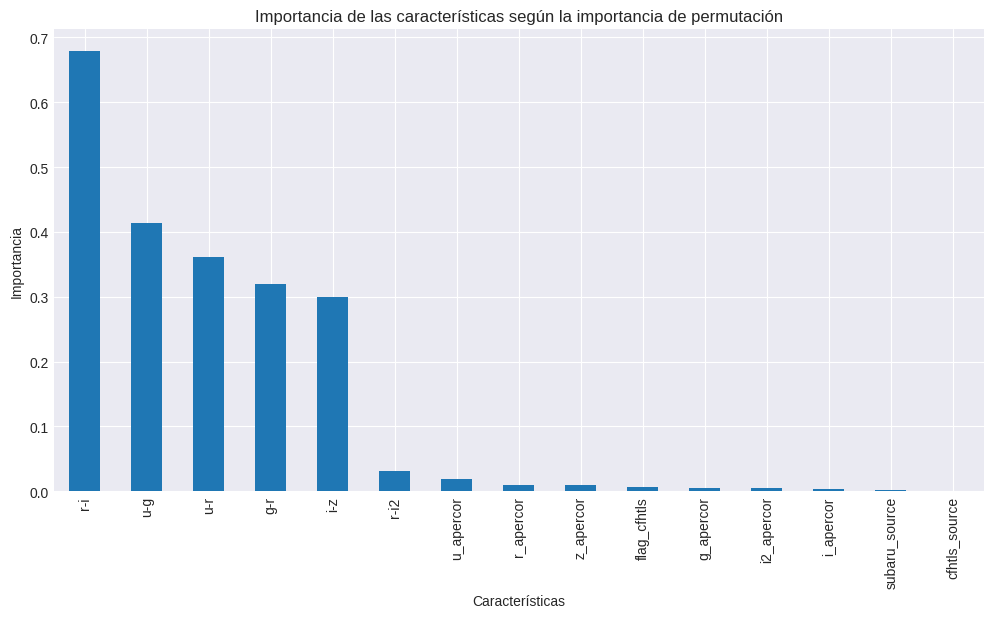

In [ ]:
from sklearn.inspection import permutation_importance
result = permutation_importance(bestModel, X_HGB, Y, n_repeats=10, random_state=42, n_jobs=-1, scoring="r2")

importances_perm = pd.Series(result.importances_mean, index=X_HGB.columns).sort_values(ascending=False)
print("Importancia de las características según la importancia de permutación:")
print(importances_perm)

importances_perm.plot(kind='bar', figsize=(12, 6))
plt.xlabel("Características")
plt.ylabel("Importancia")
plt.title("Importancia de las características según la importancia de permutación")
plt.show()

In [ ]:
#Búsqueda fina de hiperparámetros para HistGradientBoostingRegressor
param_grid_fine = {"learning_rate": [0.08, 0.09, 0.1, 0.11, 0.12],
                   "max_leaf_nodes" : [57, 61, 63, 65, 67],
                   "max_depth" : [6, 7, 8, 9, 10, None],
                   "min_samples_leaf": [23, 27, 30, 33, 35],
                   "l2_regularization": [0.0, 1e-3, 1e-2, 1e-1, 1.0]}

kf = KFold(n_splits=10, shuffle=True, random_state=42)
HGB_model_fine = HistGradientBoostingRegressor(random_state=42, categorical_features=flags, max_iter=500,
                                               early_stopping=True, n_iter_no_change=15, tol=1e-5)

HGB_finetuning = RandomizedSearchCV(HGB_model_fine, param_grid_fine, n_iter=60,
                                    cv=kf, scoring="neg_mean_squared_error", random_state=42, n_jobs=-1,
                                    return_train_score=True, verbose=1)
HGB_finetuning.fit(X_HGB, Y)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=HistGradientBoostingRegressor(categorical_features=['flag_cfhtls',
                                                                                 'cfhtls_source',
                                                                                 'subaru_source'],
                                                           early_stopping=True,
                                                           max_iter=500,
                                                           n_iter_no_change=15,
                                                           random_state=42,
                                                           tol=1e-05),
                   n_iter=400, n_jobs=-1,
                   param_distributions={'l2_regularization': [0.0, 0.001, 0.01,
                                                              0.1, 1.0],
                                        'learning_rate': [0.03, 0.04, 0.05,
                                                          0.06, 0.07],
                                        'max_depth': [6, 7, 8, 9, 10, None],
                                        'max_leaf_nodes': [57, 61, 63, 65, 67],
                                        'min_samples_leaf': [23, 27, 30, 33,
                                                             35]},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error')

In [ ]:
print("Mejores hiperparámetros encontrados (fine-tuning):")
print(HGB_finetuning.best_params_)
print(f"Mejor MSE encontrado (fine-tuning): {-HGB_finetuning.best_score_:.4f}")

Mejores hiperparámetros encontrados (fine-tuning):
{'min_samples_leaf': 27, 'max_leaf_nodes': 63, 'max_depth': None, 'learning_rate': 0.06, 'l2_regularization': 0.1}
Mejor MSE encontrado (fine-tuning): 0.0287


Number of iterations: 97


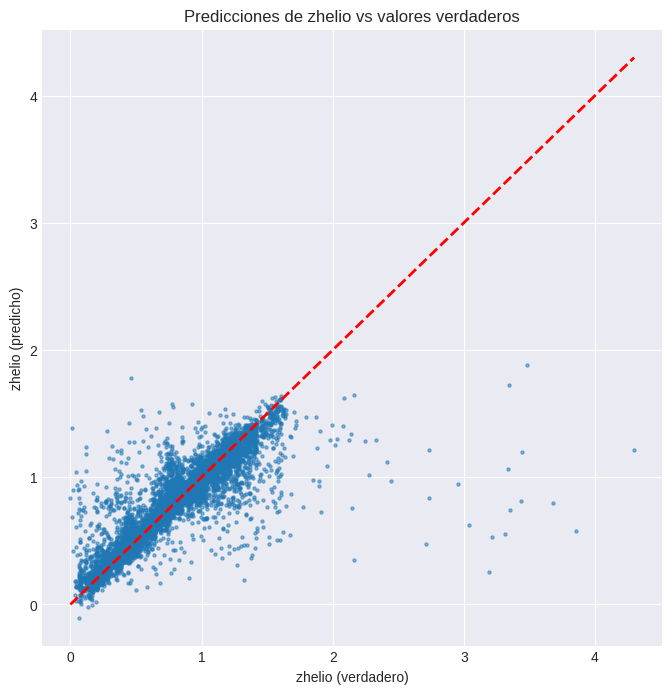

In [ ]:
from sklearn.model_selection import cross_val_predict
bestModel_finetuning = HGB_finetuning.best_estimator_
z_predict2 = cross_val_predict(bestModel_finetuning, X_HGB, Y, cv=kf)

print(f"Number of iterations: {bestModel_finetuning.n_iter_}")
plt.figure(figsize=(8, 8))
plt.scatter(Y, z_predict2, alpha=0.5, s=5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
plt.xlabel("zhelio (verdadero)")
plt.ylabel("zhelio (predicho)")
plt.title("Predicciones de zhelio vs valores verdaderos")
plt.show()

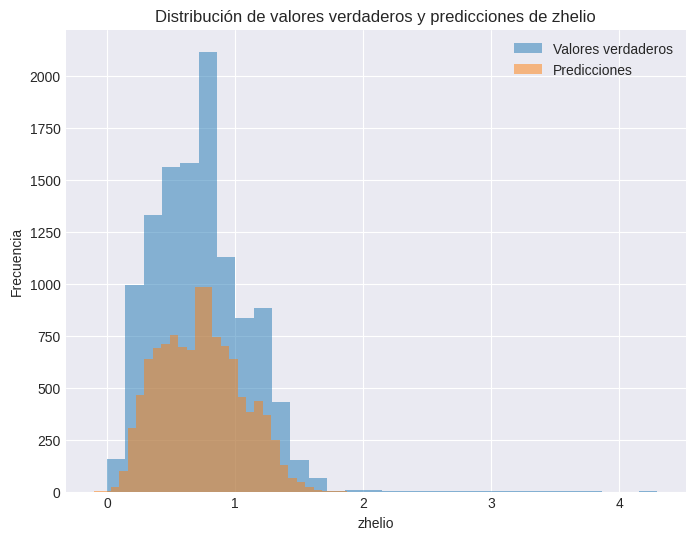

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(Y, bins=30, alpha=0.5, label="Valores verdaderos")
plt.hist(z_predict2, bins=30, alpha=0.5, label="Predicciones")
plt.xlabel("zhelio")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de valores verdaderos y predicciones de zhelio")
plt.show()

Importancia de las características según la importancia de permutación (fine-tuning):
r-i              0.445208
u-r              0.376263
g-r              0.326918
i-z              0.315594
u-g              0.280331
u_apercor        0.031131
r-i2             0.022070
z_apercor        0.013224
r_apercor        0.007262
g_apercor        0.006470
i_apercor        0.006322
i2_apercor       0.004872
flag_cfhtls      0.003341
subaru_source    0.002655
cfhtls_source    0.000097
dtype: float64


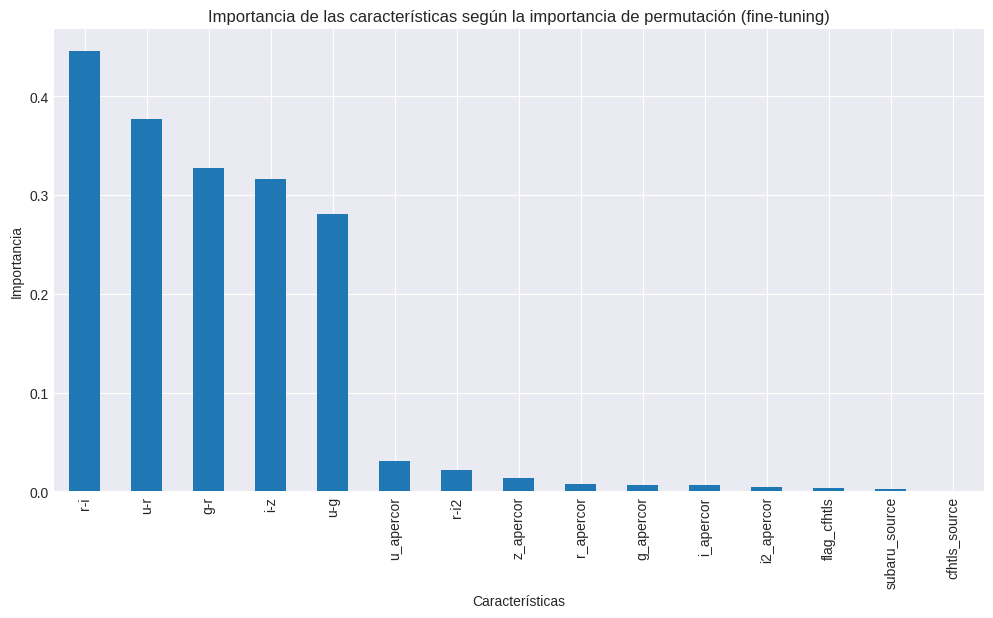

In [ ]:
result_finetuning = permutation_importance(bestModel_finetuning, X_HGB, Y, n_repeats=10, random_state=42, n_jobs=-1, scoring="r2")
importances_perm_finetuning = pd.Series(result_finetuning.importances_mean, index=X_HGB.columns).sort_values(ascending=False)
print("Importancia de las características según la importancia de permutación (fine-tuning):")
print(importances_perm_finetuning)

importances_perm_finetuning.plot(kind='bar', figsize=(12, 6))
plt.xlabel("Características")
plt.ylabel("Importancia")
plt.title("Importancia de las características según la importancia de permutación (fine-tuning)")
plt.show()

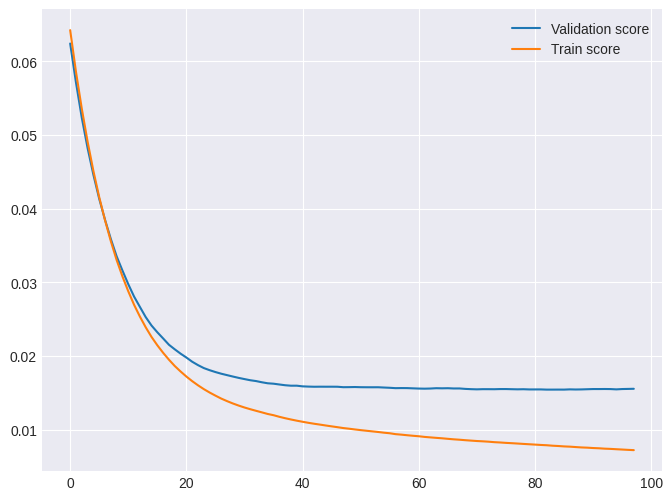

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(-bestModel_finetuning.validation_score_, label="Validation score")
plt.plot(-bestModel_finetuning.train_score_, label="Train score")
plt.legend()

In [ ]:
mseHGB_original, sigma_HGB_original, outlier_HGB_original = metrics(Y, z_predict2)
print(f"MSE del modelo con fine-tuning: {MSE(Y, z_predict2):.4f}")
print(f"Sigma NMAD del modelo con fine-tuning: {sigma_nmad(Y, z_predict2):.4f}")
print(f"Fracción de outliers del modelo con fine-tuning: {outlier_fraction(Y, z_predict2):.4f}")

MSE del modelo con fine-tuning: 0.0288
Sigma NMAD del modelo con fine-tuning: 0.0286
Fracción de outliers del modelo con fine-tuning: 0.0541


Text(0.5, 1.0, 'Residuo normalizado vs zhelio (verdadero)')

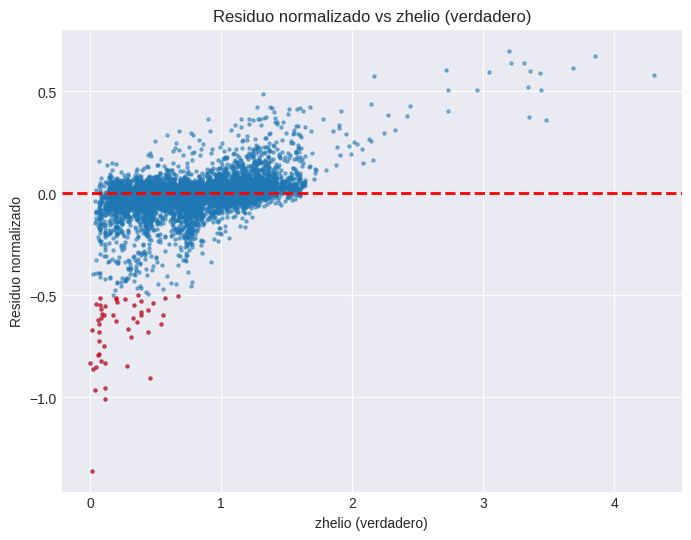

In [ ]:
residueZ = (Y - z_predict2) / (1+Y)
outliers = residueZ < -0.5


plt.figure(figsize=(8, 6))
plt.scatter(Y, residueZ, alpha=0.5, s=5)
plt.scatter(Y[outliers], residueZ[outliers], color='r', alpha=0.5, s=5, label='Outliers')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel("zhelio (verdadero)")
plt.ylabel("Residuo normalizado")
plt.title("Residuo normalizado vs zhelio (verdadero)")

In [ ]:
# Colores originales
X["u-g"] = X["u_apercor"] - X["g_apercor"]
X["g-r"] = X["g_apercor"] - X["r_apercor"]
X["r-i"] = X["r_apercor"] - X["i_apercor"]
X["i-z"] = X["i_apercor"] - X["z_apercor"]
X["r-i2"] = X["r_apercor"] - X["i2_apercor"]
X["u-r"] = X["u_apercor"] - X["r_apercor"]

# Nuevos colores
X["g-i"] = X["g_apercor"] - X["i_apercor"]
X["g-z"] = X["g_apercor"] - X["z_apercor"]
X["u-i"] = X["u_apercor"] - X["i_apercor"]
X["u-z"] = X["u_apercor"] - X["z_apercor"]
X["r-z"] = X["r_apercor"] - X["z_apercor"]

Se incorporan índices de color adicionales para evaluar si contienen información complementaria que permita mejorar la estimación del redshift.

Se actualiza el conjunto de características utilizado por HistGradientBoostingRegressor incorporando los nuevos índices de color.
Luego, se reemplazan los valores 99 por NaN para que el modelo
pueda tratarlos de forma nativa.

In [ ]:
X_HGB_colors = X.copy()

# Reemplazo de valores 99 por NaN
X_HGB_colors[bands] = X_HGB_colors[bands].replace(99, np.nan)

# Eliminación de los flags de valores faltantes, ya que HGB maneja NaN de forma nativa
X_HGB_colors.drop(
    columns=[f"{band.split('_')[0]}_is99" for band in bands] +
            [f"{band.split('_')[0]}_isneg99" for band in bands],
    inplace=True)

In [ ]:
print(X_HGB_colors.columns)

Index(['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor',
       'z_apercor', 'flag_cfhtls', 'cfhtls_source', 'subaru_source', 'u-g',
       'g-r', 'r-i', 'i-z', 'r-i2', 'u-r', 'g-i', 'g-z', 'u-i', 'u-z', 'r-z'],
      dtype='object')


In [ ]:
# Resultados: HGB + nuevos colores

HGB_colors = RandomizedSearchCV(
    HGB_model,
    param_grid,
    n_iter=85,
    cv=kf,
    scoring="neg_mean_squared_error",
    random_state=42, n_jobs = -1,
    return_train_score=True).fit(X_HGB_colors, Y)

z_predict_colors = cross_val_predict(
  HGB_colors.best_estimator_,
  X_HGB_colors,
  Y,
  cv=kf)


mse_hgb_colores = MSE(Y, z_predict_colors)
nmad_hgb_colores = sigma_nmad(Y, z_predict_colors)
out_hgb_colores = outlier_fraction(Y, z_predict_colors)

print(f"MSE (HGB + colores): {mse_hgb_colores:.5f}")
print(f"Sigma NMAD (HGB + colores): {nmad_hgb_colores:.5f}")
print(f"Fracción de outliers (HGB + colores): {out_hgb_colores:.5f}")

MSE (HGB + colores): 0.02755
Sigma NMAD (HGB + colores): 0.02910
Fracción de outliers (HGB + colores): 0.05066


In [ ]:
mse_hgb_original = MSE(Y, z_predict2)
nmad_hgb_original = sigma_nmad(Y, z_predict2)
out_hgb_original = outlier_fraction(Y, z_predict2)

comparacion = pd.DataFrame({
    "Modelo": ["HGB original", "HGB + colores"],
    "MSE": [mse_hgb_original, mse_hgb_colores],
    "NMAD": [nmad_hgb_original, nmad_hgb_colores],
    "Outliers": [out_hgb_original, out_hgb_colores]
})

comparacion

,Modelo,MSE,NMAD,Outliers
0,HGB original,0.02875,0.028597,0.054121
1,HGB + colores,0.02755,0.029100,0.050661


<Axes: >

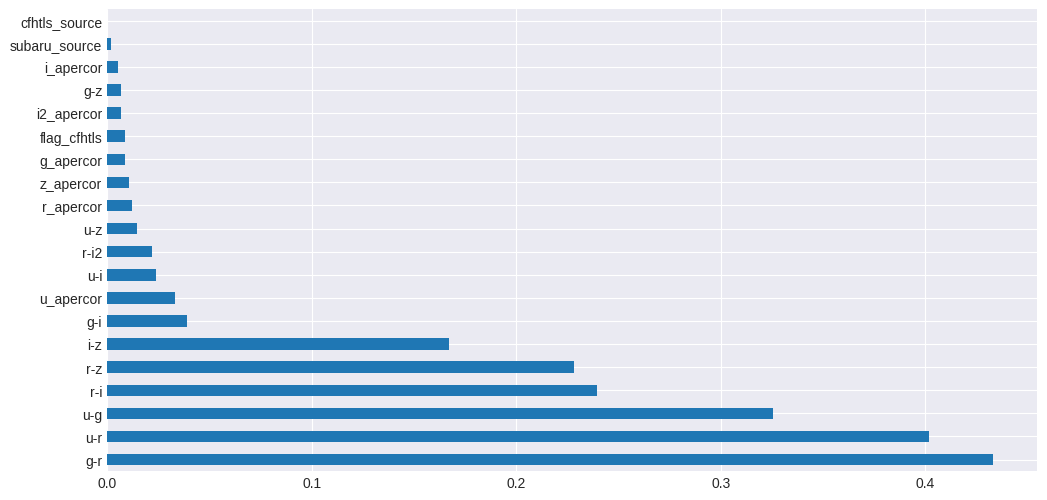

In [ ]:
perm_colors = permutation_importance(
    HGB_colors.best_estimator_,
    X_HGB_colors,
    Y,
    n_repeats=10,
    random_state=42,
    scoring="r2", n_jobs=-1)
norm_importances = perm_colors.importances / perm_colors.importances.sum(axis=0)
cumulative_importances = norm_importances.cumsum(axis=0)

mean_importances_color = pd.Series(
    perm_colors.importances_mean,
    index=X_HGB_colors.columns
).sort_values(ascending=False)

mean_importances_color.plot(
    kind="barh",
    figsize=(12,6))

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cumulative_importances) + 1), cumulative_importances.values, marker="o")
plt.axhline(0.9, color="r", linestyle="--", lw=1)
plt.xticks(range(1, len(cumulative_importances) + 1), cumulative_importances.index, rotation=98)
plt.xlabel("Características ordenadas")
plt.ylabel("Importancia acumulada")
plt.title("Importancia acumulada de las características")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

Se evaluó la incorporación de nuevos índices de color buscando aportar información fotométrica adicional al modelo. Sin embargo, las métricas obtenidas fueron idénticas a las del modelo original, indicando que estas nuevas variables no mejoran la capacidad predictiva del HistGradientBoostingRegressor. Sugiriendo que la información contenida en dichos índices ya estaba representada por los colores originales utilizados. La única columna que presentó mayor relevancia fue `r-z`, por lo que se añadirá junto con las que ya estaban.

In [ ]:
# log(1+z)

Y_log = np.log1p(Y)
X_HGB.drop(columns=["g-i", "g-z", "u-i", "u-z"], inplace=True)

In [ ]:
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_leaf_nodes": [15, 31, 63, 127],
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_leaf": [25, 57, 63, 75, 91],
    "loss" : ["squared_error", "absolute_error"]}

HGB_model_log = HistGradientBoostingRegressor(
    random_state=42,
    categorical_features=flags,
    max_iter=200, early_stopping=True, n_iter_no_change=15, tol=1e-5)

HGB_tuning_log = RandomizedSearchCV(
    HGB_model_log,
    param_grid,
    n_iter=75,
    cv=kf,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    return_train_score=True)

HGB_tuning_log.fit(X_HGB, Y_log)

print(HGB_tuning_log.best_params_)

{'min_samples_leaf': 11, 'max_leaf_nodes': 127, 'max_depth': 10, 'loss': 'absolute_error', 'learning_rate': 0.05}


In [ ]:
bestModel_log = HGB_tuning_log.best_estimator_

z_predict_log = cross_val_predict(
    bestModel_log,
    X_HGB,
    Y_log,
    cv=kf
)

# Escala original
z_predict = np.expm1(z_predict_log)
metrics(Y, z_predict)

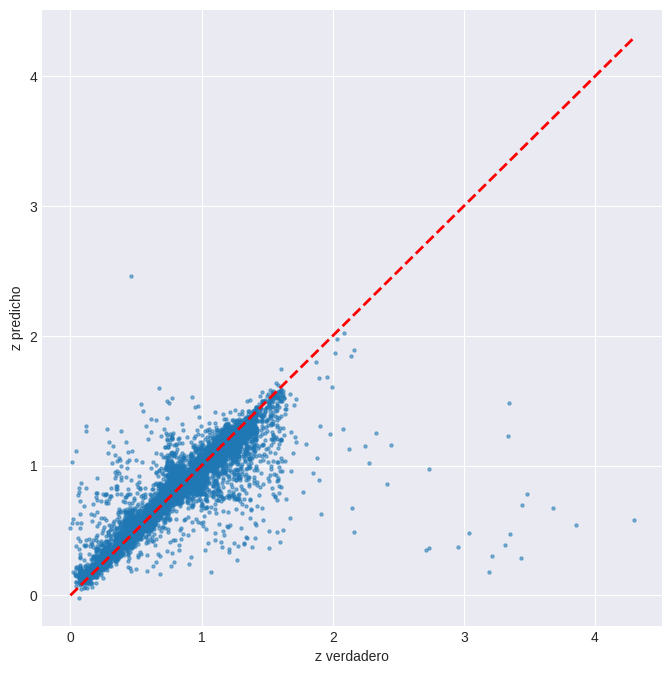

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(Y, z_predict, alpha=0.5, s=5)

plt.plot(
    [Y.min(), Y.max()],
    [Y.min(), Y.max()],
    "r--",
    lw=2)

plt.xlabel("z verdadero")
plt.ylabel("z predicho")
plt.show()

In [ ]:
param_grid_fine = {"max_leaf_nodes" : [59, 61, 63, 65, 67],
                   "max_depth" : [None, 2, 4, 8, 10],
                   "min_samples_leaf": [17, 23, 25, 27, 30],
                   "learning_rate" : [0.05, 0.1, 0.2, 0.25, 0.3],
                   "l2_regularization": [0.0, 1e-3, 1e-1, 1.0],}

HGBmodel_log = HistGradientBoostingRegressor(
    random_state=42,
    categorical_features=flags,
    max_iter=200, early_stopping=True, n_iter_no_change=15, tol=1e-5)

HGB_finetuning_log = RandomizedSearchCV(
    HGBmodel_log,
    param_grid_fine,
    n_iter=60,
    cv=kf,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    return_train_score=True)

HGB_finetuning_log.fit(X_HGB, Y_log)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=HistGradientBoostingRegressor(categorical_features=['flag_cfhtls',
                                                                                 'cfhtls_source',
                                                                                 'subaru_source'],
                                                           early_stopping=True,
                                                           max_iter=200,
                                                           n_iter_no_change=15,
                                                           random_state=42,
                                                           tol=1e-05),
                   n_iter=400, n_jobs=-1,
                   param_distributions={'l2_regularization': [0.0, 0.001, 0.1,
                                                              1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.07],
                                        'max_depth': [8, 10, 12, 15],
                                        'max_leaf_nodes': [25, 29, 31, 33, 37],
                                        'min_samples_leaf': [25, 27, 30, 33,
                                                             35]},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error')

In [ ]:
bestModel_finetuning_log = HGB_finetuning_log.best_estimator_

z_predict2_log = cross_val_predict(
    bestModel_finetuning_log,
    X_HGB,
    Y_log,
    cv=kf)

# Volviendo a z
z_predict2 = np.expm1(z_predict2_log)

In [ ]:
mseLog, nmadLog, outLog metrics(Y, z_predict2_log)

MSE: 0.02948
NMAD: 0.03018
Outliers: 0.05155


Se entrenó el mismo modelo utilizando la transformación log(1+z) como variable objetivo. En este caso se observó un ligero aumento del MSE, pero una disminución tanto de la dispersión robusta (NMAD) como de la fracción de outliers. Esto indica que la transformación logarítmica reduce la influencia de errores extremos y produce predicciones más robustas, aunque a costa de un pequeño incremento en el error cuadrático medio.

In [ ]:
comparacion = pd.DataFrame({
    "Modelo": [
        "HGB original",
        "HGB + nuevos colores",
        "HGB + log(1+z)"],
    "MSE": [
        mse_hgb_original,
        mse_hgb_colores,
        mseLog],
    "NMAD": [
        nmad_hgb_original,
        nmad_hgb_colores,
        nmadLog],
    "Outliers": [
        out_hgb_original,
        out_hgb_colors,
        outLog]})

comparacion

,Modelo,MSE,NMAD,Outliers
0,HGB original,0.027045,0.028056,0.053298
1,HGB + nuevos colores,0.027045,0.028056,0.053298
2,HGB + log(1+z),0.028000,0.027000,0.049530


Si el objetivo es minimizar el error cuadrático medio, el modelo original presenta el mejor desempeño. En cambio, si se busca reducir la dispersión robusta y la cantidad de outliers, la transformación log(1+z) ofrece mejores resultados. Dado que en problemas de estimación de redshift fotométrico las métricas NMAD y la fracción de outliers son muy utilizadas para evaluar la calidad de las predicciones, la transformación logarítmica es una alternativa interesante.

In [ ]:
# Continuamos con RandomForest
from sklearn.ensemble import RandomForestRegressor

kf_rf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]}

In [ ]:
# Se crea el modelo base que será optimizado.

RF_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1)

In [ ]:
# RandomizedSearchCV evalúa distintas combinaciones aleatorias de hiperparámetros utilizando validación cruzada
RF_tuning = RandomizedSearchCV(
    RF_model,
    param_grid_rf,
    n_iter=75,
    cv=kf,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    return_train_score=True)

RF_tuning.fit(X, Y)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
# Mostramos los hiperparámetros que obtuvieron el menor error promedio durante la validación cruzada
print("Mejores hiperparámetros:")
print(RF_tuning.best_params_)

print(f"MSE: {-RF_tuning.best_score_:.5f}")

In [ ]:
# Se recupera el mejor modelo encontrado durante la búsqueda
bestRF = RF_tuning.best_estimator_

# Se generan predicciones mediante validación cruzada
z_predict_RF = cross_val_predict(
    bestRF,
    X,
    Y,
    cv=kf,
    n_jobs=-1)

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(Y, z_predict_RF, alpha=0.5, s=5)

plt.plot(
    [Y.min(),Y.max()],
    [Y.min(),Y.max()],
    "r--",
    lw=2)

plt.xlabel("zhelio verdadero")
plt.ylabel("zhelio predicho")
plt.title("Random Forest")
plt.show()

In [ ]:
# Se calculan las mismas métricas utilizadas en los experimentos anteriores para permitir una comparación directa
mse_rf = MSE(Y, z_predict_RF)
nmad_rf = sigma_nmad(Y, z_predict_RF)
out_rf = outlier_fraction(Y, z_predict_RF)

print(f"MSE: {mse_rf:.5f}")
print(f"NMAD: {nmad_rf:.5f}")
print(f"Outliers: {out_rf:.5f}")

In [ ]:
from sklearn.inspection import permutation_importance

# Se evalúa la importancia de cada variable medianteimportancia por permutación.
result_rf = permutation_importance(
    bestRF,
    X,
    Y,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1)

importances_rf = pd.Series(
    result_rf.importances_mean,
    index=X.columns
).sort_values(ascending=False)

importances_rf.plot(
    kind="bar",
    figsize=(12,6))

plt.ylabel("Importancia")
plt.title("Random Forest")
plt.show()

In [ ]:
comparacion = pd.DataFrame({
    "Modelo":[
        "HGB original",
        "HGB + nuevos colores",
        "HGB + log(1+z)",
        "Random Forest"],
    "MSE":[
        0.027045,
        0.027045,
        0.028000,
        mse_rf],
    "NMAD":[
        0.028056,
        0.028056,
        0.027000,
        nmad_rf],
    "Outliers":[
        0.053298,
        0.053298,
        0.049530,
        out_rf]})

comparacion

Se optimizan los hiperparámetros de ExtraTreesRegressor mediante RandomizedSearchCV para comparar su desempeño con HistGradientBoosting y Random Forest.

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold

kf_et = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

param_grid_et = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]}

In [ ]:
# Se crea el modelo base de Extra Trees que será optimizado
ET_model = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1)

In [ ]:
print(param_grid_et)

{'n_estimators': [100, 200, 300, 500], 'max_depth': [None, 10, 20, 30, 50], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2', None]}


In [ ]:
print(param_grid_et.keys())

dict_keys(['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features'])


In [ ]:
# Se realiza una búsqueda aleatoria de hiperparámetros utilizando validación cruzada
# para identificar la configuración con menor error de predicción.
ET_tuning = RandomizedSearchCV(
    ET_model,
    param_grid_et,
    n_iter=75,
    cv=kf_et,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    return_train_score=True)

# Entrenamiento
ET_tuning.fit(X, Y)



/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=ExtraTreesRegressor(n_jobs=-1, random_state=42),
                   n_iter=75, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 50],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error')

In [ ]:
# Se muestran los mejores hiperparámetros encontrados
print("Mejores hiperparámetros:")
print(ET_tuning.best_params_)

print(f"MSE: {-ET_tuning.best_score_:.5f}")


Mejores hiperparámetros:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
MSE: 0.02669


In [ ]:
from sklearn.model_selection import cross_val_predict
# Se recupera el modelo con mejor desempeño obtenido
bestModel_ET = ET_tuning.best_estimator_

# Se generan predicciones mediante validación cruzada.
z_predict_ET = cross_val_predict(
    bestModel_ET,
    X,
    Y,
    cv=kf_et,
    n_jobs=-1)

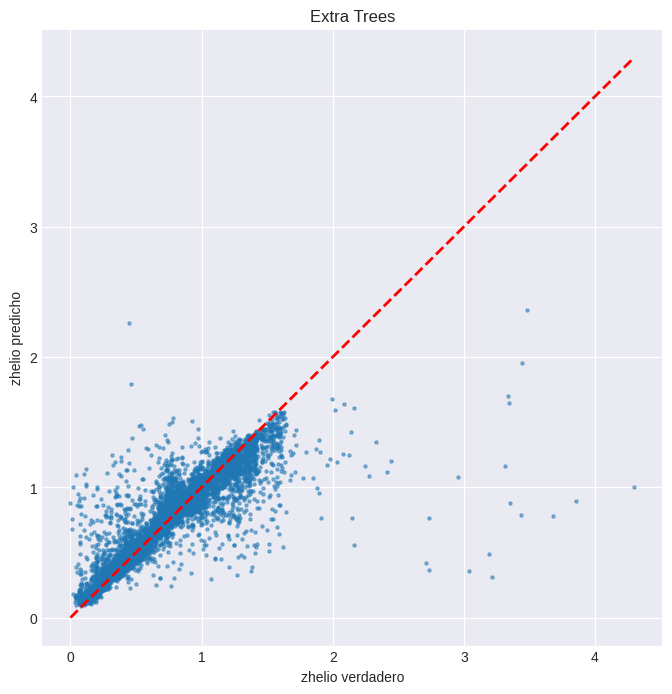

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(Y, z_predict_ET, alpha=0.5, s=5)
plt.plot(
    [Y.min(), Y.max()],
    [Y.min(), Y.max()],
    "r--",
    lw=2)

plt.xlabel("zhelio verdadero")
plt.ylabel("zhelio predicho")
plt.title("Extra Trees")
plt.show()

In [ ]:
# Se calculan las mismas métricas utilizadas en los modelos anteriores para comparar el desempeño.
mse_et = MSE(Y, z_predict_ET)
nmad_et = sigma_nmad(Y, z_predict_ET)
out_et = outlier_fraction(Y, z_predict_ET)

print(f"MSE: {mse_et:.5f}")
print(f"NMAD: {nmad_et:.5f}")
print(f"Outliers: {out_et:.5f}")

MSE: 0.02669
NMAD: 0.02371
Outliers: 0.04880


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


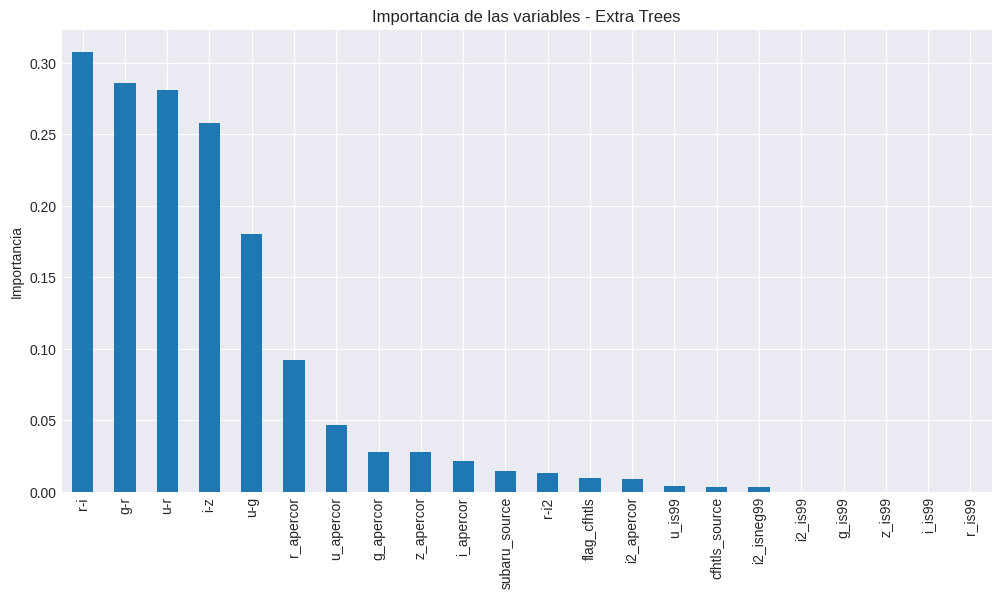

In [ ]:
from sklearn.inspection import permutation_importance
# Evaluamos la importancia de cada variable mediante importancia por permutación.
result_et = permutation_importance(
    bestModel_ET,
    X,
    Y,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1)

importances_et = pd.Series(
    result_et.importances_mean,
    index=X.columns).sort_values(ascending=False)

importances_et.plot(kind="bar", figsize=(12,6))

plt.ylabel("Importancia")
plt.title("Importancia de las variables - Extra Trees")
plt.show()

In [ ]:
# Borrar
ET_tuning = RandomizedSearchCV(
    estimator=ET_model,
    param_distributions=param_grid_et,
    n_iter=75,
    cv=kf_et,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    return_train_score=True)

ET_tuning.fit(X_train, Y_train_log)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=ExtraTreesRegressor(n_jobs=-1, random_state=42),
                   n_iter=75, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 50],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error')

In [ ]:
# Probamos con log
kf_et = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

param_grid_et = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]}

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold

Y_log = np.log1p(Y)

# Creamos un nuevo modelo Extra Trees
ET_model_log = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1)

# Búsqueda de hiperparámetros
ET_tuning_log = RandomizedSearchCV(
    estimator=ET_model_log,
    param_distributions=param_grid_et,
    n_iter=75,
    cv=kf_et,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    return_train_score=True)

# Entrenamiento utilizando log(1+z)
ET_tuning_log.fit(X, Y_log)

# Mostramos los mejores hiperparámetros
print("Mejores hiperparámetros para Extra Trees + log(1+z):")
print(ET_tuning_log.best_params_)

print(f"Mejor MSE en espacio logarítmico: {-ET_tuning_log.best_score_:.5f}")

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores hiperparámetros para Extra Trees + log(1+z):
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
Mejor MSE en espacio logarítmico: 0.00649


In [ ]:
from sklearn.model_selection import cross_val_predict
# Modelo optimizado con log(1+z)
bestModel_ET_log = ET_tuning_log.best_estimator_

# Predicciones de log(1+z) mediante validación cruzada
z_predict_ET_log = cross_val_predict(
    bestModel_ET_log,
    X,
    Y_log,
    cv=kf_et,
    n_jobs=-1)

# Volvemos desde log(1+z) al espacio original de redshift
z_predict_ET_log = np.expm1(z_predict_ET_log)

# Calculamos las mismas métricas utilizadas para el modelo original
mse_etlog = MSE(Y, z_predict_ET_log)
nmad_etlog = sigma_nmad(Y, z_predict_ET_log)
out_etlog = outlier_fraction(Y, z_predict_ET_log)

print(f"MSE: {mse_etlog:.5f}")
print(f"NMAD: {nmad_etlog:.5f}")
print(f"Outliers: {out_etlog:.5f}")

MSE: 0.02776
NMAD: 0.02341
Outliers: 0.04747


## Ajuste definitivo

In [ ]:
# Creación de Pipeline ordenado para los modelos.
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import FunctionTransformer

source_cols = ["cfhtls_source", "subaru_source"]
#Dado que los valores 247 y 253 son pocos, se agrupan en sólo una categoría para el encoder
flag_map = {
    0: "0",
    244: "244",
    252: "252",
    1: "grp_other",
    247: "grp_other",
    253: "grp_other",
}
colorsToBuild = ["u-g", "g-r", "r-i", "i-z", "u-r", "r-z", "r-i2"]

class PhotometryFeatureEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, mag_cols=None, flag_col="flag_cfhtls", percentile=97):
        self.mag_cols = mag_cols
        self.flag_col = flag_col
        self.percentile = percentile
#Cálculo de mediana para cada banda
    def fit(self, X, y=None):
        self.mag_cols_ = list(self.mag_cols if self.mag_cols is not None else [c for c in X.columns if c.endswith("_apercor")])
        self.thresholds_ = {}
        for band in self.mag_cols_:
            validValues = X[band][(X[band] != 99) & (X[band] != -99)]
            if not validValues.empty:
                self.thresholds_[band] = validValues.quantile( self.percentile / 100)
        return self

    def transform(self, X):
        X = X.copy()
#Creación de flags cuando la magnitud es 99 y reemplazo por mediana de la banda
#Además se limpian los -99, reemplazado por NaN para que el imputer los lleve
        for col in self.mag_cols_:
            band_name = col.split('_')[0]
            X[f"{band_name}_is99"] = (X[col] == 99).astype(np.int8)
            X.loc[X[col] == 99, col] = self.thresholds_.get(col)
            if any(X[col] == -99):
                X[f"{band_name}_isneg99"] = (X[col] == -99).astype(np.int8)
                X.loc[X[col] == -99, col] = np.nan
#Tratamiento de flag_cfhtls
        if self.flag_col in X.columns:
            X[self.flag_col] = X[self.flag_col].map(flag_map).fillna("other").astype(str)

        return X

#Construcción de colores
class ColorBuilder(BaseEstimator, TransformerMixin):
    def __init__(self, mag_cols=None, colors=None):
        self.mag_cols = mag_cols if mag_cols is not None else ["u_apercor", "g_apercor", "r_apercor", "i_apercor", "z_apercor"]
        self.colors = colors if colors is not None else colorsToBuild
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for color in self.colors:
            band1, band2 = color.split("-")
            X[color] = X[f"{band1}_apercor"] - X[f"{band2}_apercor"]
        return X


try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

#Preprocesamiento de datos, común para los modelos
preprocessor = Pipeline(steps=[
    ("feat", PhotometryFeatureEncoder(mag_cols=bands)),
    ("colorBuilder", ColorBuilder(mag_cols=bands, colors=colorsToBuild)),
    ("encode", ColumnTransformer(
        transformers=[
            ("cat", ohe, source_cols + ["flag_cfhtls"]),
        ],
        remainder="passthrough",
        verbose_feature_names_out=False,
    ))
])
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.compose import TransformedTargetRegressor

from sklearn.impute import SimpleImputer#lopusoame,quitar
ETR_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesRegressor(random_state=42, bootstrap=True, oob_score=True, n_jobs=1))])
param_grid_et = {
    "model__n_estimators": [200, 500, 700, 1000],
    "model__max_depth": [None, 10, 15, 20, 30],
    "model__max_features": ["sqrt", 0.3, 0.5, 0.7, 1.0],
    "model__min_samples_leaf": np.random.randint(5, 50, size=5).tolist(),
    "model__min_samples_split": np.random.randint(2, 20, size=5).tolist(),
    "_model__max_samples": [0.6, 0.8, None],
}
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ETR = TransformedTargetRegressor(regressor = ETR_pipeline, transformer=np.log1p, inverse_func=np.expm1)
ET_tuning = HalvingRandomSearchCV(
    ETR, param_grid_et,
    resource="_model__n_estimators",
    max_resources=1000,
    min_resources=100,
    factor=3,
    cv=kf,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2,
)



In [ ]:
# Datos de entrenamiento previamente filtrados
X_train = cleanedTrain.copy().drop(columns=redshift)
X_train.drop(columns=metadata, inplace=True)

Y_train = cleanedTrain["zhelio"].copy()

In [ ]:
# Optimización de Extra Trees usando log(1+z) como variable objetivo
ET_tuning.fit(X_train, Y_train)

In [ ]:
from sklearn.trees import DecisionTreeRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
DT_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeRegressor(random_state=42))])

DT = TransformedTargetRegressor

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import RandomizedSearchCV, KFold, HalvingRandomSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor

RF_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, bootstrap=True, oob_score=True, n_jobs=1))])

RF = TransformedTargetRegressor(
    regressor=RF_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)
param_grid = {"regressor__model__max_depth": [None, 10, 15, 20, 30],
              "regressor__model__max_features": ["sqrt", 0.3, 0.5, 0.7],
              "regressor__model__min_samples_leaf": np.random.randint(5, 50, size=5).tolist(),
              "regressor__model__min_samples_split": np.random.randint(2, 20, size=5).tolist()
              }
kf = KFold(n_splits=5, shuffle=True, random_state=42)
RF_tuning = HalvingRandomSearchCV(RF, param_grid, n_candidates=100, cv=kf, resource="regressor__model__n_estimators", max_resources=1000,
                                  min_resources=200, factor=10,
                                  scoring="neg_mean_squared_error", random_state=42, n_jobs=-1, return_train_score=True, verbose=1)

#RF_tuning.fit(X_train, Y_train)


In [ ]:
param_grid_fine = {
    "regressor__model__max_depth": [20, 25, 30, 35, None],
    "regressor__model__max_features": [0.3, 0.4, 0.5, 0.6, 0.7],
    "regressor__model__min_samples_leaf": [4, 6, 8, 10, 12, 15],
    "regressor__model__min_samples_split": [8, 12, 16, 20, 24],
}

RF_finetuning = HalvingRandomSearchCV(
    RF, param_grid_fine, n_candidates=100, cv=kf,
    resource="regressor__model__n_estimators",
    max_resources=1000, min_resources=200, factor=3,
    scoring="neg_mean_squared_error", random_state=42,
    n_jobs=-1, return_train_score=True, verbose=1
)
#RF_finetuning.fit(X_train, Y_train)

El modelo final fue regularizado a mano, y es el que se presenta a continuación. Destacar que no fue entrenado en Colab, sino en un ambiente local.

In [ ]:
#El modelo fue entrenado en ambiente local, acá solamente se cargará
import joblib
RF_final = joblib.load("RF_pipeline_regularized.joblib")
print("Parámetros finales para RandomForest")
RF_final

Parámetros finales para RandomForest


TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessing',
                                                      Pipeline(steps=[('feat',
                                                                       PhotometryFeatureEncoder(mag_cols=['u_apercor',
                                                                                                          'g_apercor',
                                                                                                          'r_apercor',
                                                                                                          'i_apercor',
                                                                                                          'i2_apercor',
                                                                                                          'z_apercor'])),
                                                                      ('colorBuilder',
                                                                       ColorBuilder(colors=['u-g',
                                                                                            'g-r',
                                                                                            'r-i',
                                                                                            'i-z',
                                                                                            'u-r',
                                                                                            'r-z',
                                                                                            'r-i2'],
                                                                                    mag_cols=['u_ape...
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_output=False),
                                                                                                        ['cfhtls_source',
                                                                                                         'subaru_source',
                                                                                                         'flag_cfhtls'])],
                                                                                         verbose_feature_names_out=False))])),
                                                     ('imputer',
                                                      SimpleImputer(strategy='median')),
                                                     ('model',
                                                      RandomForestRegressor(max_depth=35,
                                                                            max_features=0.4,
                                                                            min_samples_leaf=4,
                                                                            min_samples_split=8,
                                                                            n_estimators=600,
                                                                            n_jobs=-1,
                                                                            oob_score=True,
                                                                            random_state=42))]))

In [ ]:

print("Métricas en train")
_ = metrics(Y_train, RF_final.predict(X_train))
print("Métricas en holdout")
_ = metrics(Y_holdout, RF_final.predict(X_holdout))


Métricas en train
MSE: 0.0158
Sigma NMAD: 0.0141
Fracción de outliers: 0.0264
Métricas en holdout
MSE: 0.0225
Sigma NMAD: 0.0229
Fracción de outliers: 0.0442


Destacar que las métricas evidencian un leve sobreajuste, pero no dejan de ser buenas en general.

Text(0.5, 1.0, 'Random Forest Pipeline Regularizado: Predicciones vs Valores Verdaderos')

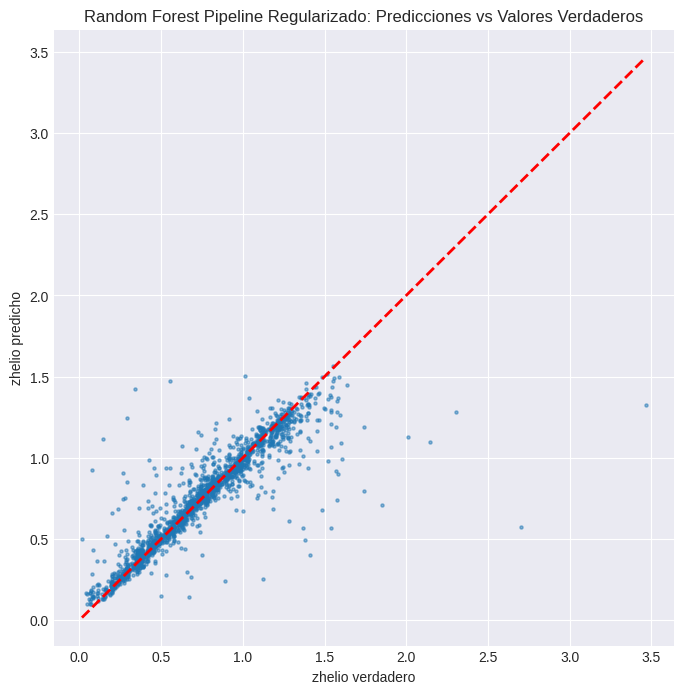

In [ ]:
Y_holdout_predict = RF_final.predict(X_holdout)
plt.figure(figsize=(8, 8))
plt.plot([Y_holdout.min(), Y_holdout.max()], [Y_holdout.min(), Y_holdout.max()], 'r--', lw=2)
plt.scatter(Y_holdout, RF_final.predict(X_holdout), alpha=0.5, s=5)
plt.xlabel("zhelio verdadero")
plt.ylabel("zhelio predicho")
plt.title("Random Forest Pipeline Regularizado: Predicciones vs Valores Verdaderos")

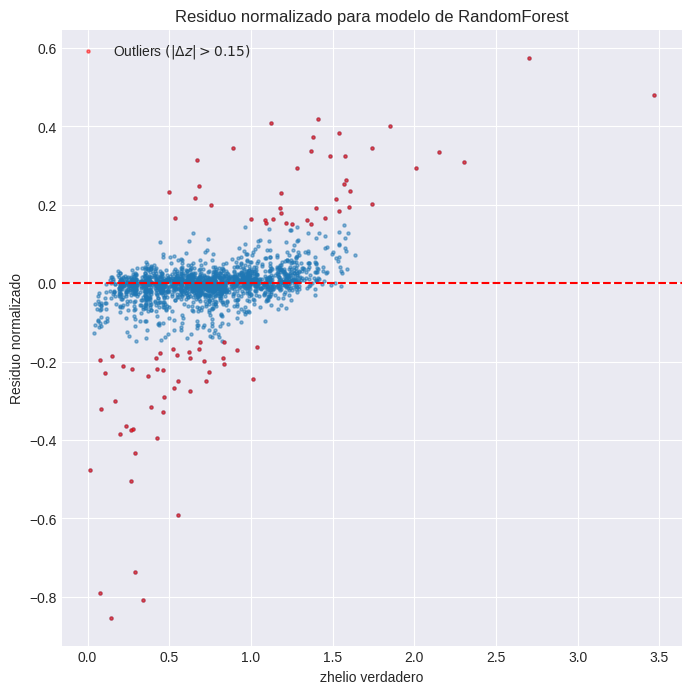

In [ ]:

residuos = (Y_holdout -Y_holdout_predict) / (1+Y_holdout)
outliers = np.abs(residuos) > 0.15
plt.figure(figsize=(8, 8))
plt.scatter(Y_holdout, residuos, alpha=0.5, s=5)
plt.scatter(Y_holdout[outliers], residuos[outliers], color='red', alpha=0.5, s=5, label=r"Outliers $(|\Delta z| > 0.15)$")
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("zhelio verdadero")
plt.ylabel("Residuo normalizado")
plt.title("Residuo normalizado para modelo de RandomForest")
plt.legend()

In [ ]:
# Datos de test y predicción
test = pd.read_csv("test_redshift.csv")
X_test = test.copy().drop(columns=metadata + ["zquality"])
Y_test_predict = RF_final.predict(X_test)

Y_test_predict
submission = pd.DataFrame({"objno_deep2" : test["objno_deep2"], "zhelio" : Y_test_predict})
submission.to_csv("predicciones.csv", index=False)

,objno_deep2,zhelio
0,12011416,0.561415
1,12023279,0.823224
2,13017399,1.026945
3,12008131,0.459570
4,12003729,0.515212
...,...,...
4760,13004618,0.752346
4761,11033821,0.473197
4762,14017734,1.285681
4763,13058149,0.408197


In [ ]:


Métricas en train
MSE: 0.0158
Sigma NMAD: 0.0141
Fracción de outliers: 0.0264
Métricas en holdout
MSE: 0.0225
Sigma NMAD: 0.0229
Fracción de outliers: 0.0442


### Recapitulación

Para comenzar, se hizo una limpieza y exploración de los datos, encontrando tres columnas categóricas además de un indicador de calidad del redshift que se usó como filtrado principal para los datos de entrenamiento. La exploración de las features concluyó en la creación de columnas de colores vecinos, junto con los colores `u-r` y `r-z`, que fueron las que presentaron mayor relevancia en el análisis de feature_importance. También se consideró la transformación en $z\to \log 1+z$, que respondía a tratar de llevar los outliers que ocurrían en la parte baja del redshift. Esto llevo a una leve mejora en los outliers, que fue considerada en el modelo final.


| Modelo        | Features usadas | Hiperparámetros principales | MSE train | MSE validación |
| ------------- | --------------- | --------------------------- | --------- | -------------- |
| Decision Tree |                 |                             |           |                |
| RandomForest      | Magnitudes, colores vecinos, colores intercalados, flags                |                             |           |                |
